In [2]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_vars(filename):
    file = uproot.open(filename)
    tree = file["T"]

    etot = tree["P.cal.etottracknorm"].array(library="np")
    delta = tree["P.gtr.dp"].array(library="np")
    z = tree["P.react.z"].array(library="np")
    y = tree["P.react.y"].array(library="np")

    xsieve = np.tan(tree["P.gtr.th"].array(library="np"))
    ysieve = np.tan(tree["P.gtr.ph"].array(library="np"))
    # xsieve = tree["P.gtr.th"].array(library="np")
    # ysieve = tree["P.gtr.ph"].array(library="np")

    cut = (
    (etot > 0.8) &
    (np.abs(delta - 5) < 15) &
    (np.abs(z) < 1)
    # (z >  9.5) & (z < 10.5)
    # (z < - 9.5) & (z > -10.5)
    )

    return xsieve[cut], ysieve[cut]

bins = [150, 150]
ranges = [[-0.06, 0.06], [-0.06, 0.06]]





## SHMS_p = $-6.358$ GeV/c

/var/folders/j6/9gzqgwz92nzg7mgfgbs2rxjm0000gn/T/ipykernel_14514/490407186.py:15: RuntimeWarning: invalid value encountered in tan
  xsieve = np.tan(tree["P.gtr.th"].array(library="np"))
/var/folders/j6/9gzqgwz92nzg7mgfgbs2rxjm0000gn/T/ipykernel_14514/490407186.py:16: RuntimeWarning: invalid value encountered in tan
  ysieve = np.tan(tree["P.gtr.ph"].array(library="np"))


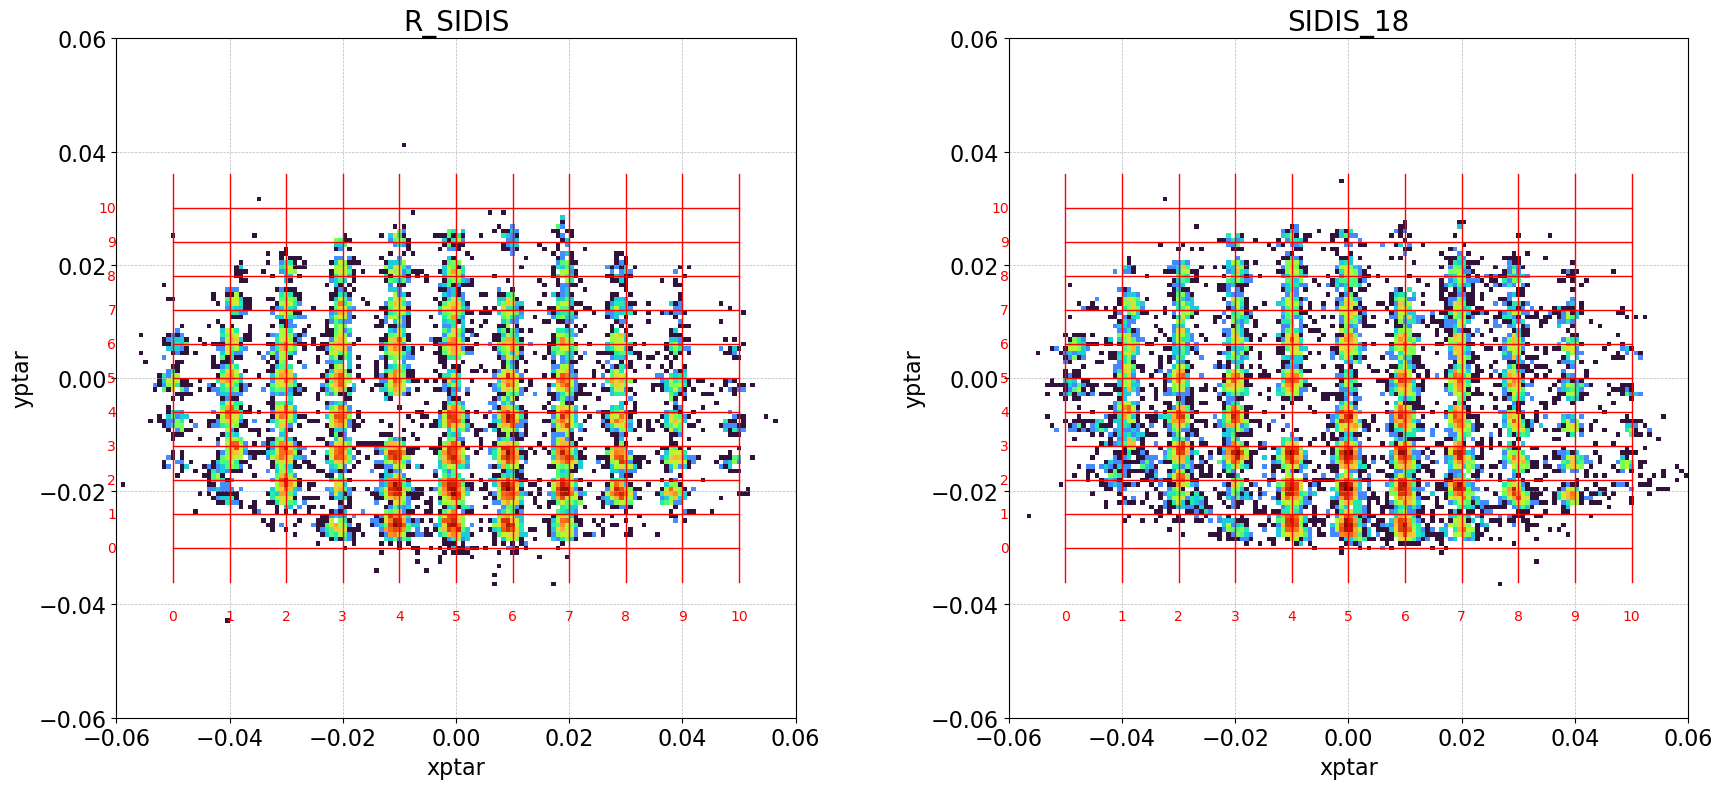

In [3]:
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16

x_r, y_r = load_vars("optics_rsidis/shms_coin_replay_production_25521_-1.root")
x_18, y_18 = load_vars("optics_sidis18/coin_replay_production_5335_-1.root")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# R_SIDIS
h1 = axes[0].hist2d(
    x_r, y_r,
    bins=bins,
    range=ranges,
    cmap="turbo",
    norm=colors.LogNorm()  # optional: ROOT defaults are log-like
)
axes[1].set_title("SIDIS_18", fontsize=20)
axes[1].set_xlabel("xptar", fontsize=16)
axes[1].set_ylabel("yptar", fontsize=16)
axes[1].set_aspect('equal', adjustable='box')
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.9)
# fig.colorbar(h1[3], ax=axes[0], label="Counts")

# SIDIS_18 
h2 = axes[1].hist2d(
    x_18, y_18,
    bins=bins,
    range=ranges,
    cmap="turbo",
    norm=colors.LogNorm()
)
axes[0].set_title("R_SIDIS", fontsize=20)
axes[0].set_xlabel("xptar", fontsize=16)
axes[0].set_ylabel("yptar", fontsize=16)
axes[0].set_aspect('equal', adjustable='box')
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.9)
# fig.colorbar(h2[3], ax=axes[1], label="Counts")

# Sieve slit ranges
x_min, x_max = -0.05, 0.05
y_min, y_max = -(0.05)*(3/5), (0.05)*(3/5)

# Scaling factors
x_scale = x_max / 8.2   # 0.05 / 8.2
y_scale = y_max / 12.5   # 0.03 / 12.5

n_lines = 11

# From Holly's script
x_positions_root = [n * 1.64 - 1.64 * 5 for n in range(n_lines)]
y_positions_root = [n * 2.5 - 2.5 * 5 for n in range(n_lines)]


for n, pos_root in enumerate(x_positions_root):
    # Scale position
    pos = pos_root * x_scale

    y1 = -15 * y_scale
    y2 =  15 * y_scale

    # Vertical lines
    axes[0].plot([pos, pos], [y1, y2], color='red', linewidth=1)
    axes[1].plot([pos, pos], [y1, y2], color='red', linewidth=1)

    y_text = (-17) * y_scale
    axes[0].text(pos, y_text, str(n), color='red', ha='center', va='top')
    axes[1].text(pos, y_text, str(n), color='red', ha='center', va='top')

for n, y_root in enumerate(y_positions_root):
    
    # Scale y position
    y = y_root * y_scale

    # Horizontal lines
    axes[0].plot([-0.05, 0.05], [y, y], color='red', linewidth=1)
    axes[1].plot([-0.05, 0.05], [y, y], color='red', linewidth=1)

    # Scaled text position
    x_text = -0.06   # shifted left slightly, like ROOT's -11.5
    axes[0].text(x_text, y, str(n), color='red', ha='right', va='center')
    axes[1].text(x_text, y, str(n), color='red', ha='right', va='center')


plt.tight_layout()
plt.show()

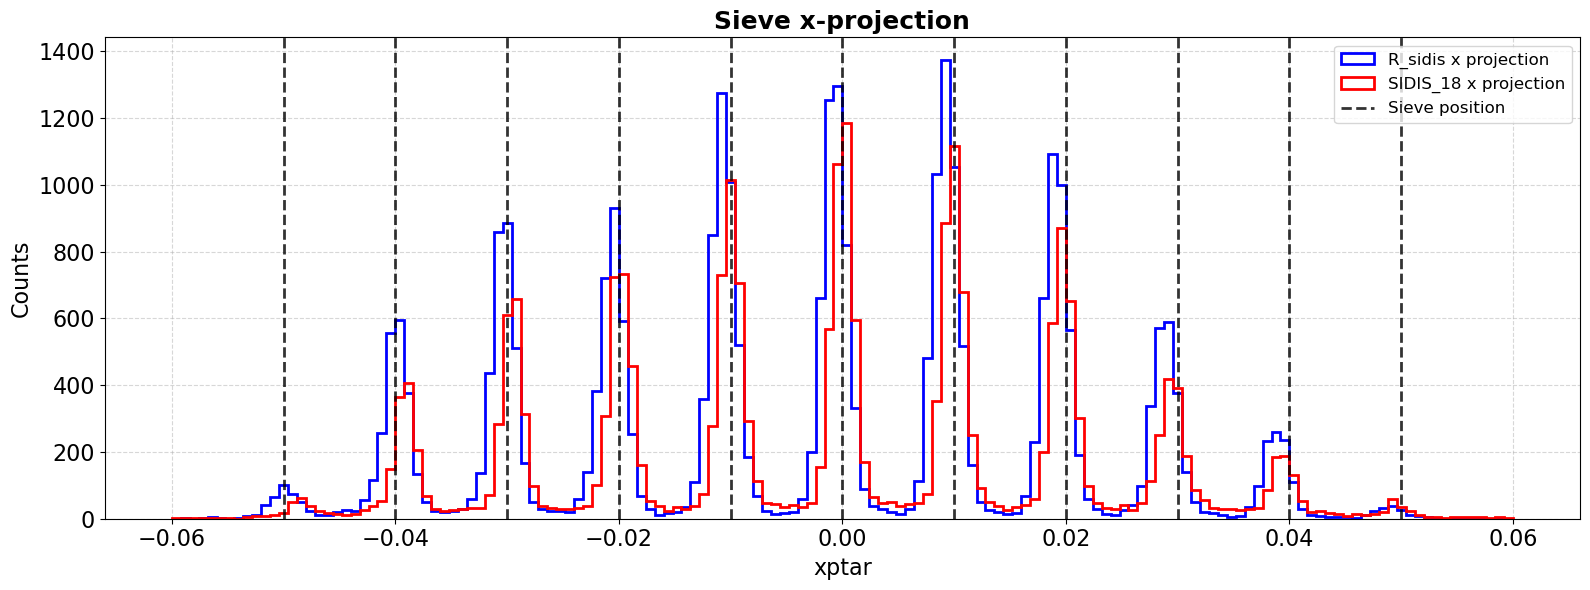

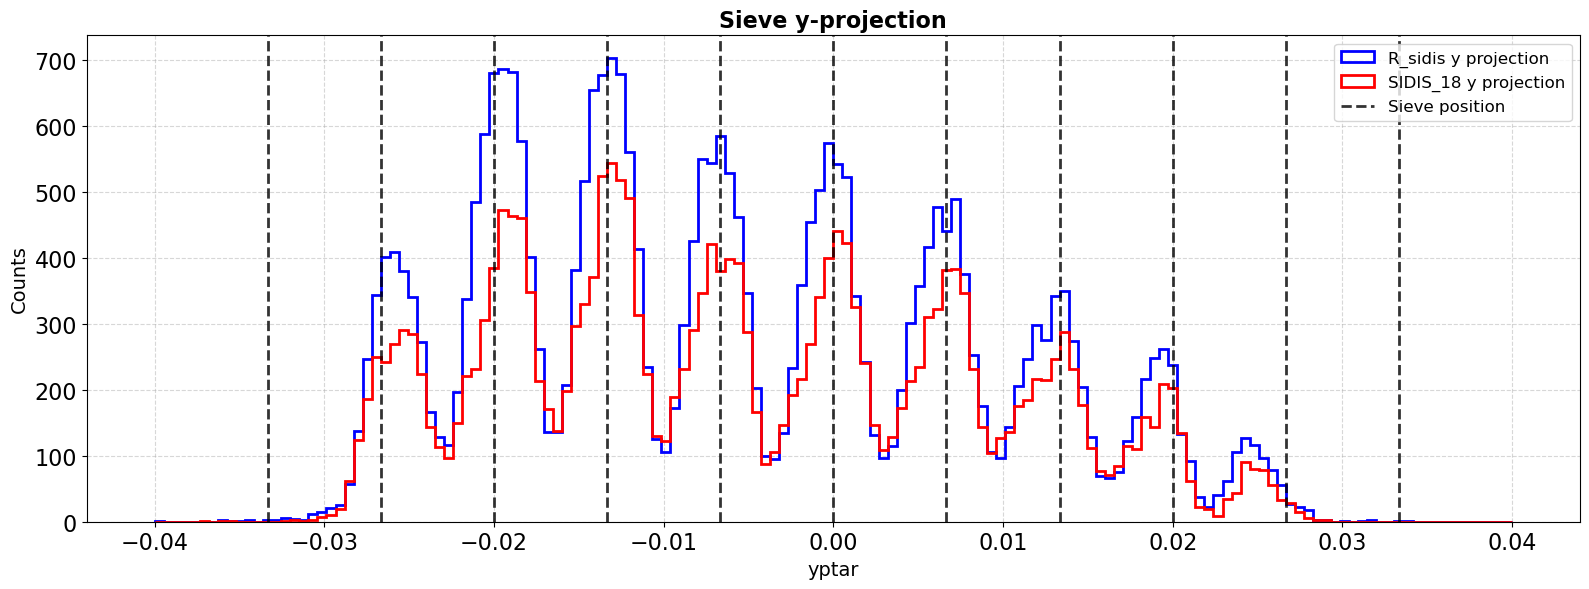

In [9]:
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16

xbins = np.linspace(-0.06, 0.06, 151) 
ybins = np.linspace(-0.04, 0.04, 151) 

# Vertical sieve lines
xs_vertical_root = [n * 1.64 - 1.64 * 5 for n in range(11)]
x_scale = 0.05 / 8.2
xs_vertical = [x * x_scale for x in xs_vertical_root]

# Horizontal sieve lines
ys_horizontal_root = [n * 2.5 - 12.5 for n in range(11)]
y_scale = (0.05 * 2/3) / 12.5
ys_horizontal = [y * y_scale for y in ys_horizontal_root]


plt.figure(figsize=(16,6))
plt.hist(x_r, bins=xbins, histtype='step', alpha=1, label="R_sidis x projection", color='blue', linewidth=2, edgecolor='blue')
plt.hist(x_18, bins=xbins, histtype='step', alpha=1, label="SIDIS_18 x projection", color='red', linewidth=2, edgecolor='red')
for x in xs_vertical:
    plt.axvline(x=x, color='k', linewidth=2, linestyle='--', alpha=0.8,label='Sieve position' if x == xs_vertical[0] else "")

plt.title("Sieve x-projection", fontsize=18, fontweight="bold")
plt.xlabel("xptar", fontsize=16)
plt.ylabel("Counts", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


plt.figure(figsize=(16,6))
plt.hist(y_r, bins=ybins, histtype='step', alpha=1, label="R_sidis y projection", color='blue', linewidth=2, edgecolor='blue')
plt.hist(y_18, bins=ybins, histtype='step', alpha=1, label="SIDIS_18 y projection", color='red', linewidth=2, edgecolor='red')
for y in ys_horizontal:
    plt.axvline(x=y, color='k', linewidth=2, linestyle='--', alpha=0.8, label='Sieve position' if y == ys_horizontal[0] else "")

plt.title("Sieve y-projection", fontsize=16, fontweight="bold")
plt.xlabel("yptar", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()



## SHMS_p = $-5.983$ GeV/c

/var/folders/j6/9gzqgwz92nzg7mgfgbs2rxjm0000gn/T/ipykernel_14514/490407186.py:15: RuntimeWarning: invalid value encountered in tan
  xsieve = np.tan(tree["P.gtr.th"].array(library="np"))
/var/folders/j6/9gzqgwz92nzg7mgfgbs2rxjm0000gn/T/ipykernel_14514/490407186.py:16: RuntimeWarning: invalid value encountered in tan
  ysieve = np.tan(tree["P.gtr.ph"].array(library="np"))


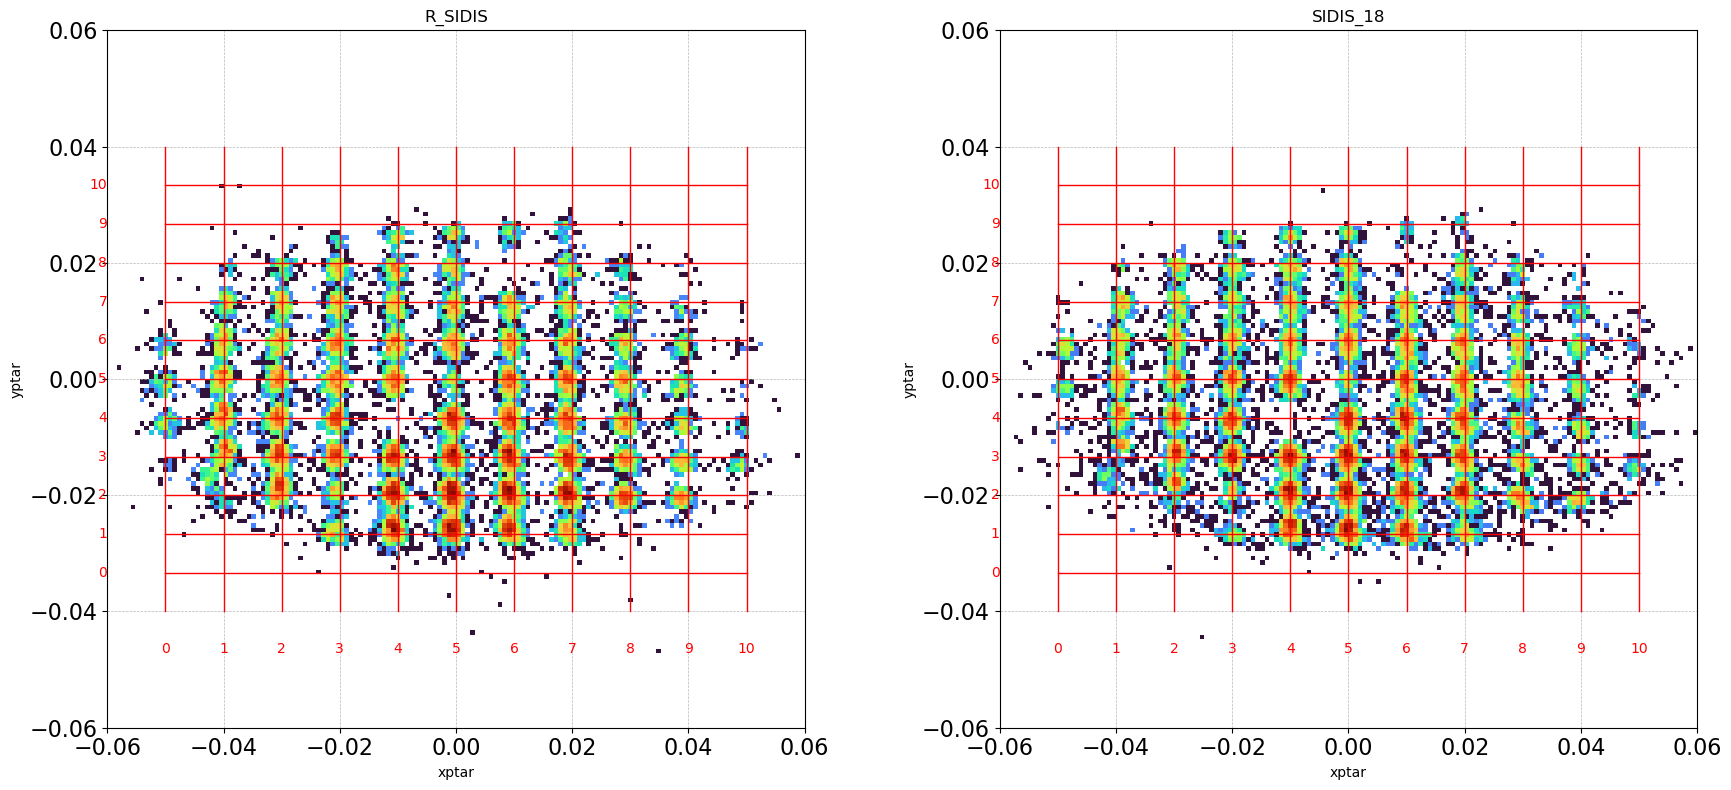

In [5]:
x_r, y_r = load_vars("optics_rsidis/shms_coin_replay_production_25527_-1.root")
x_18, y_18 = load_vars("optics_sidis18/coin_replay_production_5336_-1.root")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# R_SIDIS
h1 = axes[0].hist2d(
    x_r, y_r,
    bins=bins,
    range=ranges,
    cmap="turbo",
    norm=colors.LogNorm()  # optional: ROOT defaults are log-like
)
axes[0].set_title("R_SIDIS")
axes[0].set_xlabel("xptar")
axes[0].set_ylabel("yptar")
axes[0].set_aspect('equal', adjustable='box')
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.9)
# fig.colorbar(h1[3], ax=axes[0], label="Counts")

# SIDIS_18 
h2 = axes[1].hist2d(
    x_18, y_18,
    bins=bins,
    range=ranges,
    cmap="turbo",
    norm=colors.LogNorm()
)
axes[1].set_title("SIDIS_18")
axes[1].set_xlabel("xptar")
axes[1].set_ylabel("yptar")
axes[1].set_aspect('equal', adjustable='box')
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.9)
# fig.colorbar(h2[3], ax=axes[1], label="Counts")

# Sieve slit ranges
x_min, x_max = -0.05, 0.05
y_min, y_max = -(0.05)*(2/3), (0.05)*(2/3)

# Scaling factors
x_scale = x_max / 8.2   # 0.05 / 8.2
y_scale = y_max / 12.5   # 0.03 / 12.5

n_lines = 11

# From Holly's script
x_positions_root = [n * 1.64 - 1.64 * 5 for n in range(n_lines)]
y_positions_root = [n * 2.5 - 2.5 * 5 for n in range(n_lines)]


for n, pos_root in enumerate(x_positions_root):
    # Scale position
    pos = pos_root * x_scale

    y1 = -15 * y_scale
    y2 =  15 * y_scale

    # Vertical lines
    axes[0].plot([pos, pos], [y1, y2], color='red', linewidth=1)
    axes[1].plot([pos, pos], [y1, y2], color='red', linewidth=1)

    y_text = (-17) * y_scale
    axes[0].text(pos, y_text, str(n), color='red', ha='center', va='top')
    axes[1].text(pos, y_text, str(n), color='red', ha='center', va='top')

for n, y_root in enumerate(y_positions_root):
    
    # Scale y position
    y = y_root * y_scale

    # Horizontal lines
    axes[0].plot([-0.05, 0.05], [y, y], color='red', linewidth=1)
    axes[1].plot([-0.05, 0.05], [y, y], color='red', linewidth=1)

    # Scaled text position
    x_text = -0.06   # shifted left slightly, like ROOT's -11.5
    axes[0].text(x_text, y, str(n), color='red', ha='right', va='center')
    axes[1].text(x_text, y, str(n), color='red', ha='right', va='center')


plt.tight_layout()
plt.show()

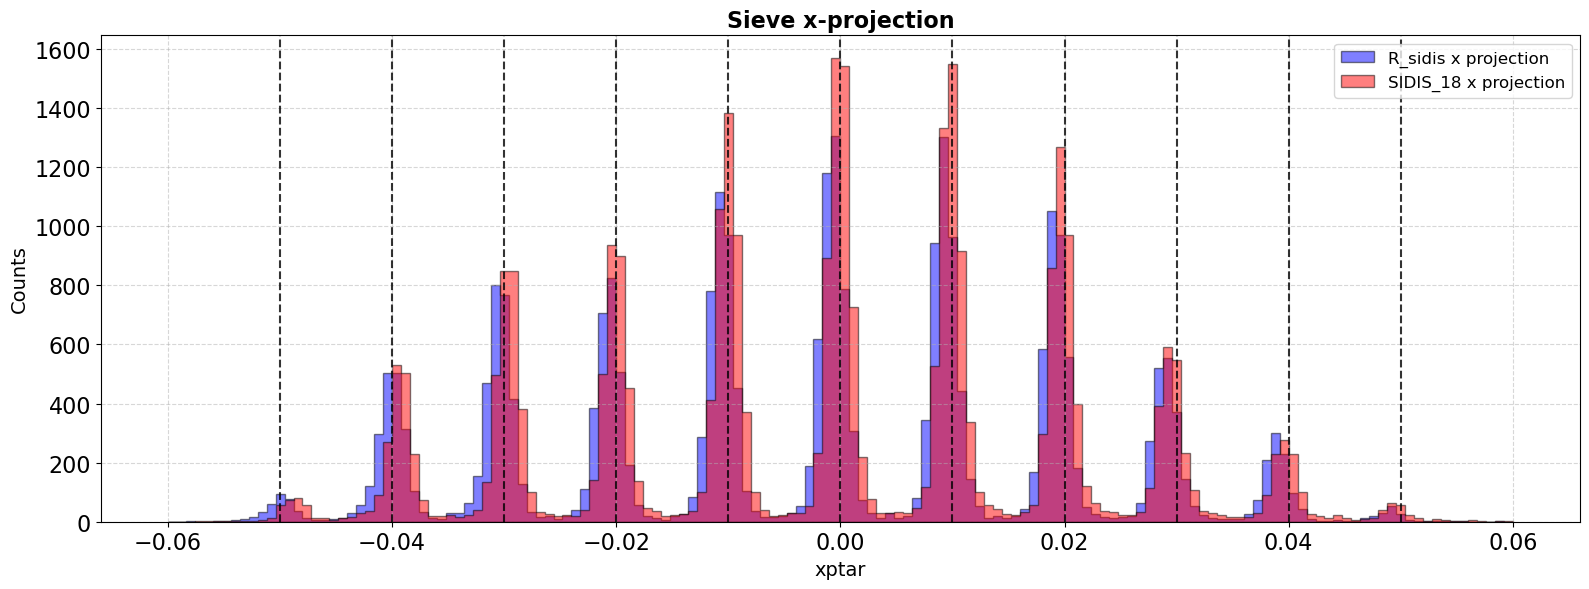

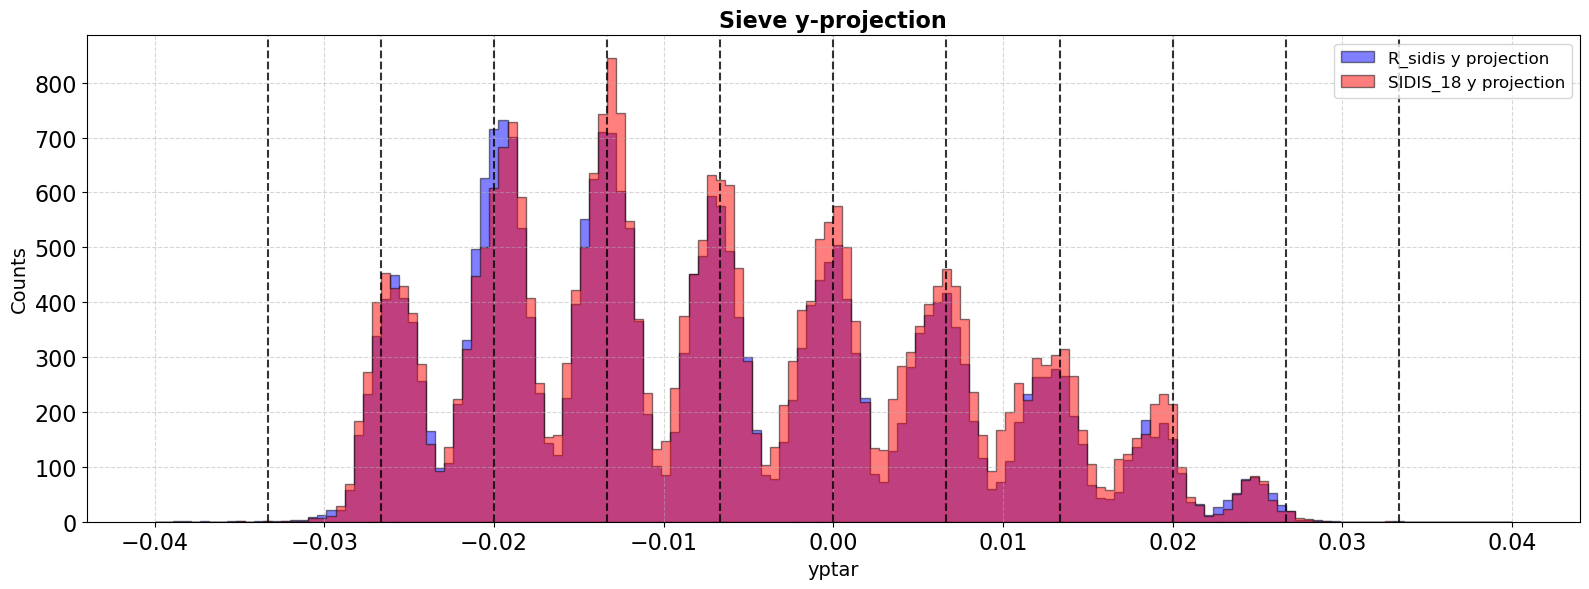

In [6]:
xbins = np.linspace(-0.06, 0.06, 151) 
ybins = np.linspace(-0.04, 0.04, 151) 

# Vertical sieve lines
xs_vertical_root = [n * 1.64 - 1.64 * 5 for n in range(11)]
x_scale = 0.05 / 8.2
xs_vertical = [x * x_scale for x in xs_vertical_root]

# Horizontal sieve lines
ys_horizontal_root = [n * 2.5 - 12.5 for n in range(11)]
y_scale = (0.05 * 2/3) / 12.5
ys_horizontal = [y * y_scale for y in ys_horizontal_root]


plt.figure(figsize=(16,6))
plt.hist(x_r, bins=xbins, histtype='stepfilled', alpha=0.5, label="R_sidis x projection", color='blue', edgecolor='black')
plt.hist(x_18, bins=xbins, histtype='stepfilled', alpha=0.5, label="SIDIS_18 x projection", color='red', edgecolor='black')
for x in xs_vertical:
    plt.axvline(x=x, color='k', linewidth=1.5, linestyle='--', alpha=0.8)

plt.title("Sieve x-projection", fontsize=16, fontweight="bold")
plt.xlabel("xptar", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


plt.figure(figsize=(16,6))
plt.hist(y_r, bins=ybins, histtype='stepfilled', alpha=0.5, label="R_sidis y projection", color='blue', edgecolor='black')
plt.hist(y_18, bins=ybins, histtype='stepfilled', alpha=0.5, label="SIDIS_18 y projection", color='red', edgecolor='black')
for y in ys_horizontal:
    plt.axvline(x=y, color='k', linewidth=1.5, linestyle='--', alpha=0.8)

plt.title("Sieve y-projection", fontsize=16, fontweight="bold")
plt.xlabel("yptar", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()



### SHMS_p = $-5.270$ GeV/c

/var/folders/j6/9gzqgwz92nzg7mgfgbs2rxjm0000gn/T/ipykernel_14514/490407186.py:15: RuntimeWarning: invalid value encountered in tan
  xsieve = np.tan(tree["P.gtr.th"].array(library="np"))
/var/folders/j6/9gzqgwz92nzg7mgfgbs2rxjm0000gn/T/ipykernel_14514/490407186.py:16: RuntimeWarning: invalid value encountered in tan
  ysieve = np.tan(tree["P.gtr.ph"].array(library="np"))


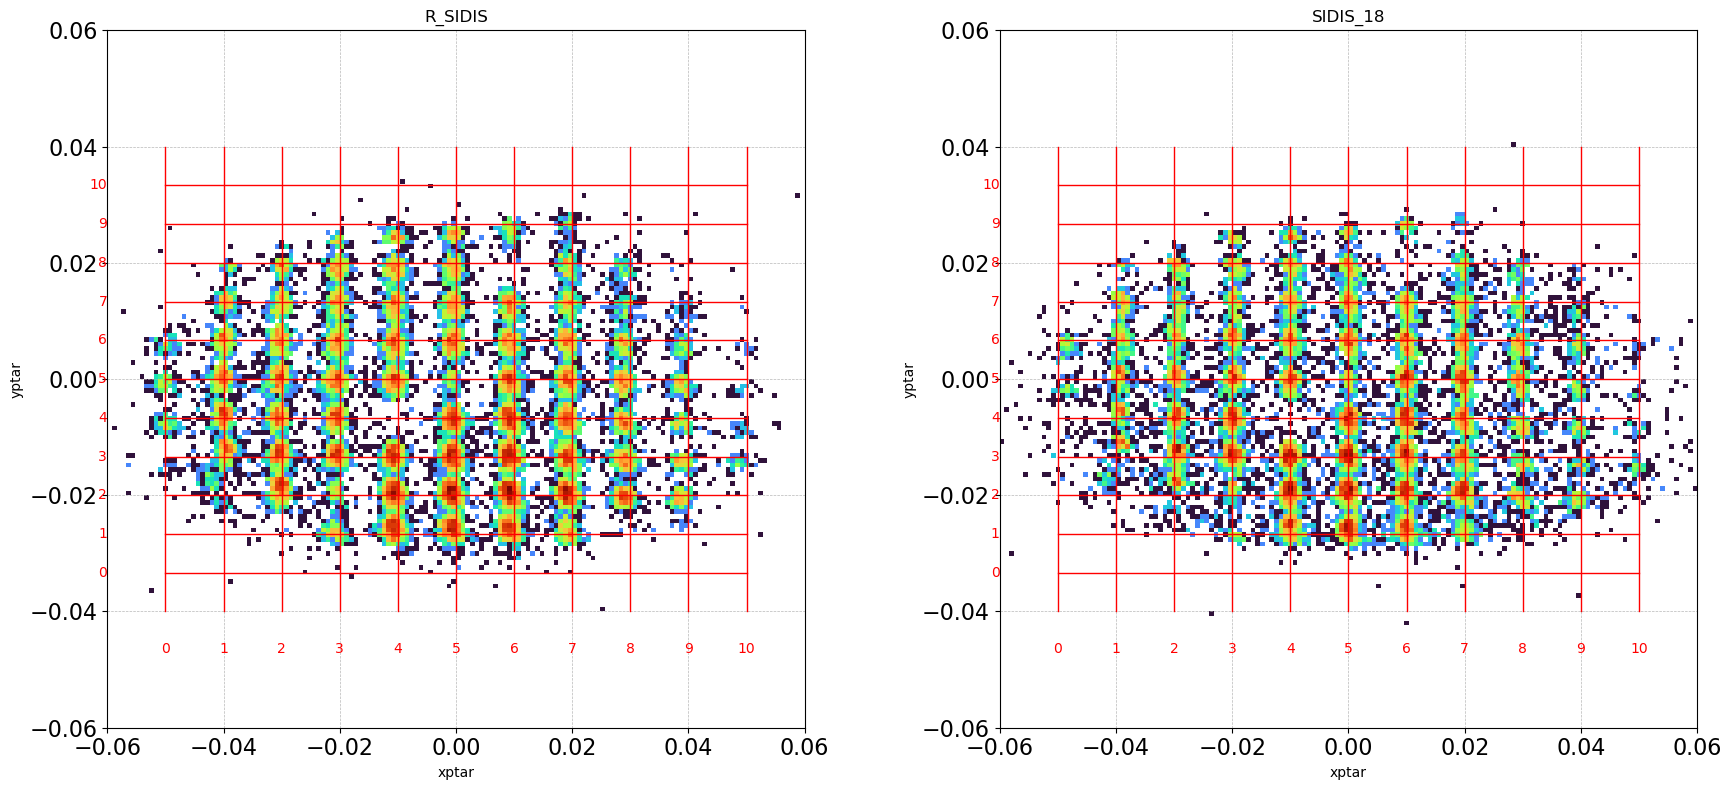

In [7]:
x_r, y_r = load_vars("optics_rsidis/shms_coin_replay_production_25529_-1.root")
x_18, y_18 = load_vars("optics_sidis18/coin_replay_production_5340_-1.root")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# R_SIDIS
h1 = axes[0].hist2d(
    x_r, y_r,
    bins=bins,
    range=ranges,
    cmap="turbo",
    norm=colors.LogNorm()  # optional: ROOT defaults are log-like
)
axes[0].set_title("R_SIDIS")
axes[0].set_xlabel("xptar")
axes[0].set_ylabel("yptar")
axes[0].set_aspect('equal', adjustable='box')
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.9)
# fig.colorbar(h1[3], ax=axes[0], label="Counts")

# SIDIS_18 
h2 = axes[1].hist2d(
    x_18, y_18,
    bins=bins,
    range=ranges,
    cmap="turbo",
    norm=colors.LogNorm()
)
axes[1].set_title("SIDIS_18")
axes[1].set_xlabel("xptar")
axes[1].set_ylabel("yptar")
axes[1].set_aspect('equal', adjustable='box')
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.9)
# fig.colorbar(h2[3], ax=axes[1], label="Counts")

# Sieve slit ranges
x_min, x_max = -0.05, 0.05
y_min, y_max = -(0.05)*(2/3), (0.05)*(2/3)

# Scaling factors
x_scale = x_max / 8.2   # 0.05 / 8.2
y_scale = y_max / 12.5   # 0.03 / 12.5

n_lines = 11

# From Holly's script
x_positions_root = [n * 1.64 - 1.64 * 5 for n in range(n_lines)]
y_positions_root = [n * 2.5 - 2.5 * 5 for n in range(n_lines)]


for n, pos_root in enumerate(x_positions_root):
    # Scale position
    pos = pos_root * x_scale

    y1 = -15 * y_scale
    y2 =  15 * y_scale

    # Vertical lines
    axes[0].plot([pos, pos], [y1, y2], color='red', linewidth=1)
    axes[1].plot([pos, pos], [y1, y2], color='red', linewidth=1)

    y_text = (-17) * y_scale
    axes[0].text(pos, y_text, str(n), color='red', ha='center', va='top')
    axes[1].text(pos, y_text, str(n), color='red', ha='center', va='top')

for n, y_root in enumerate(y_positions_root):
    
    # Scale y position
    y = y_root * y_scale

    # Horizontal lines
    axes[0].plot([-0.05, 0.05], [y, y], color='red', linewidth=1)
    axes[1].plot([-0.05, 0.05], [y, y], color='red', linewidth=1)

    # Scaled text position
    x_text = -0.06   # shifted left slightly, like ROOT's -11.5
    axes[0].text(x_text, y, str(n), color='red', ha='right', va='center')
    axes[1].text(x_text, y, str(n), color='red', ha='right', va='center')


plt.tight_layout()
plt.show()

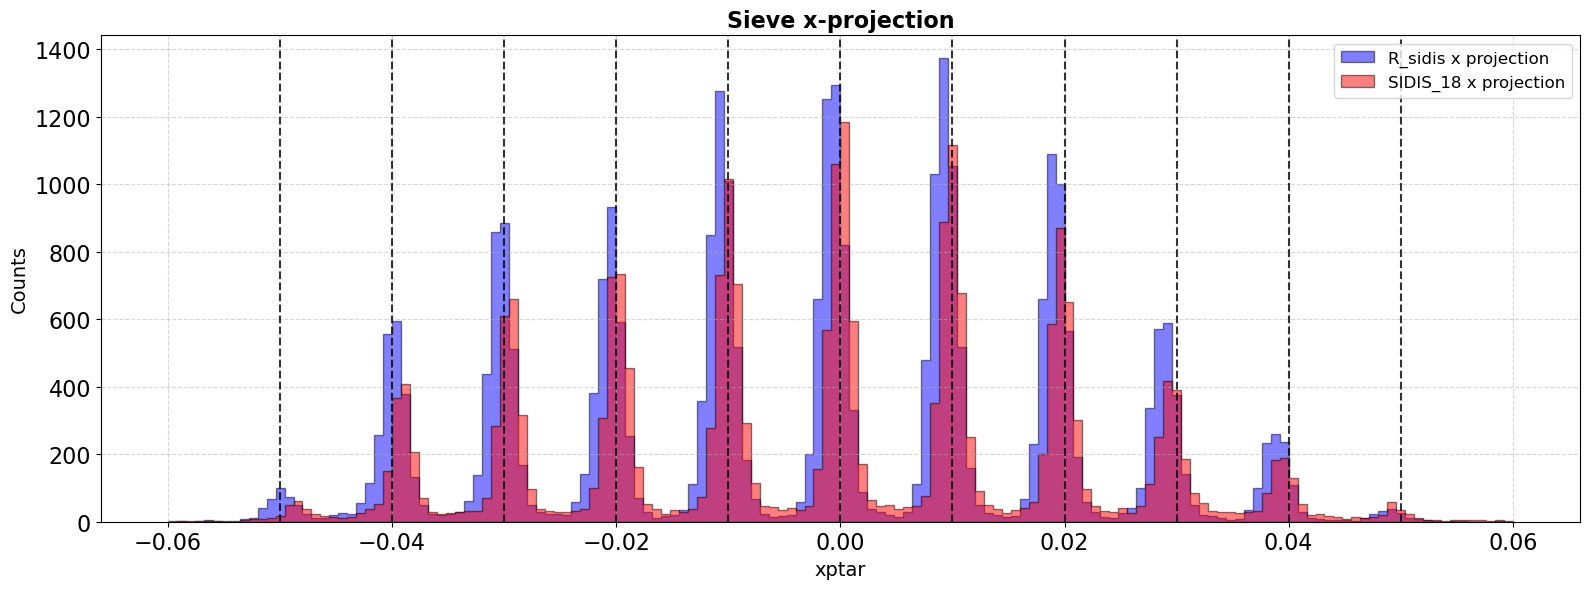

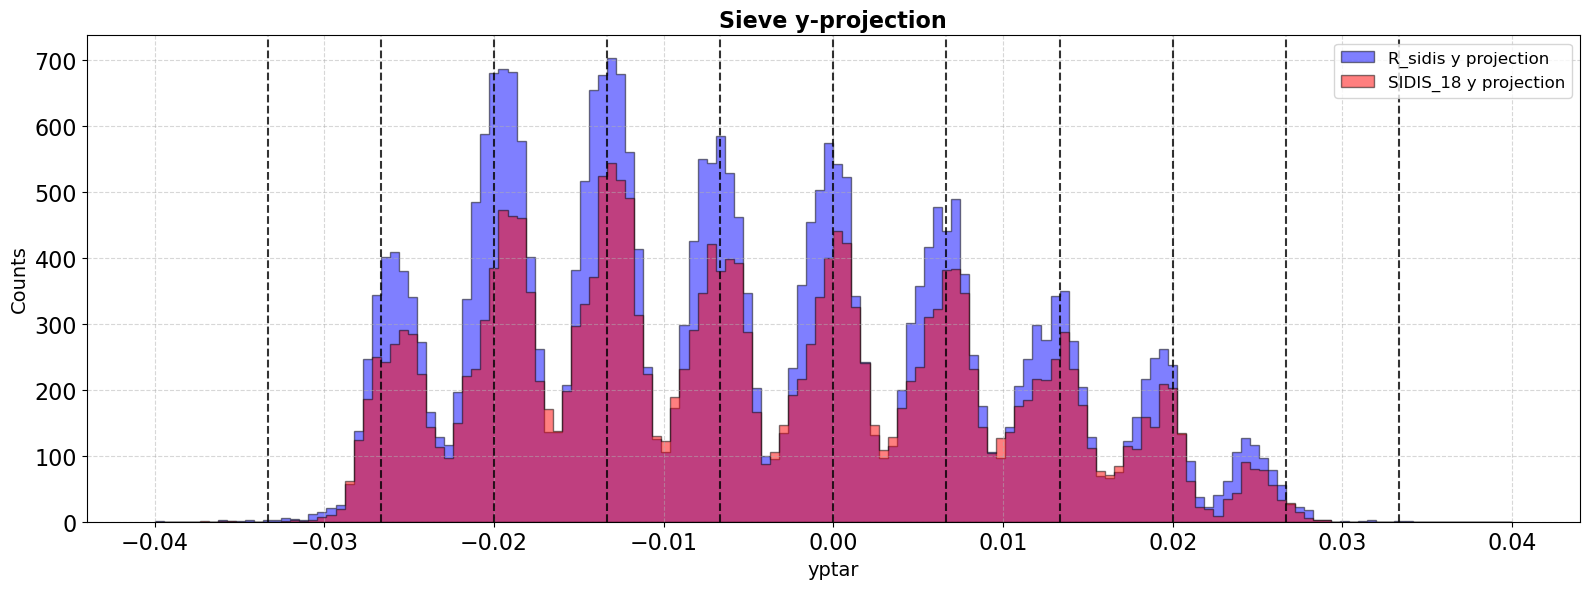

In [8]:
xbins = np.linspace(-0.06, 0.06, 151) 
ybins = np.linspace(-0.04, 0.04, 151) 

# Vertical sieve lines
xs_vertical_root = [n * 1.64 - 1.64 * 5 for n in range(11)]
x_scale = 0.05 / 8.2
xs_vertical = [x * x_scale for x in xs_vertical_root]

# Horizontal sieve lines
ys_horizontal_root = [n * 2.5 - 12.5 for n in range(11)]
y_scale = (0.05 * 2/3) / 12.5
ys_horizontal = [y * y_scale for y in ys_horizontal_root]


plt.figure(figsize=(16,6))
plt.hist(x_r, bins=xbins, histtype='stepfilled', alpha=0.5, label="R_sidis x projection", color='blue', edgecolor='black')
plt.hist(x_18, bins=xbins, histtype='stepfilled', alpha=0.5, label="SIDIS_18 x projection", color='red', edgecolor='black')
for x in xs_vertical:
    plt.axvline(x=x, color='k', linewidth=1.5, linestyle='--', alpha=0.8)

plt.title("Sieve x-projection", fontsize=16, fontweight="bold")
plt.xlabel("xptar", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


plt.figure(figsize=(16,6))
plt.hist(y_r, bins=ybins, histtype='stepfilled', alpha=0.5, label="R_sidis y projection", color='blue', edgecolor='black')
plt.hist(y_18, bins=ybins, histtype='stepfilled', alpha=0.5, label="SIDIS_18 y projection", color='red', edgecolor='black')
for y in ys_horizontal:
    plt.axvline(x=y, color='k', linewidth=1.5, linestyle='--', alpha=0.8)

plt.title("Sieve y-projection", fontsize=16, fontweight="bold")
plt.xlabel("yptar", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

